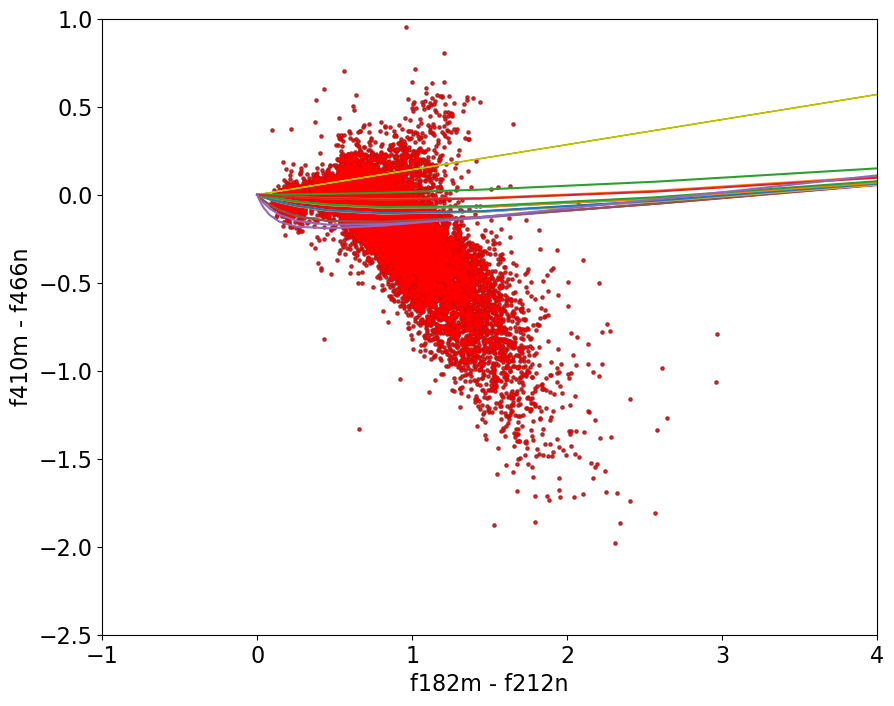

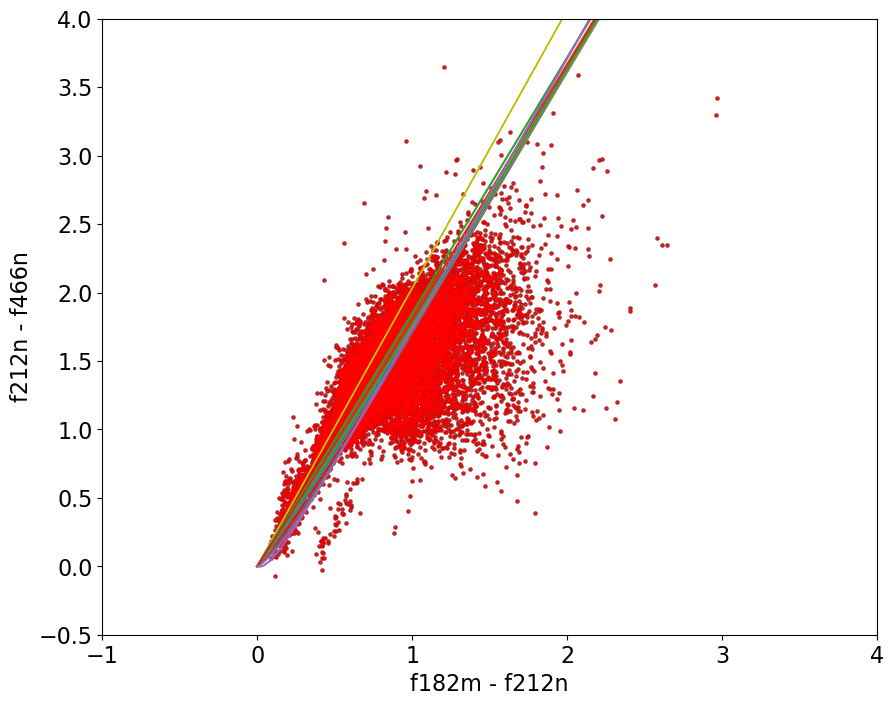

In [72]:
basepath = '/orange/adamginsburg/jwst/brick'
%run -i $basepath/analysis/make_ccd_with_icemodels.py

In [73]:
E_V_color2

0.004543222258976243

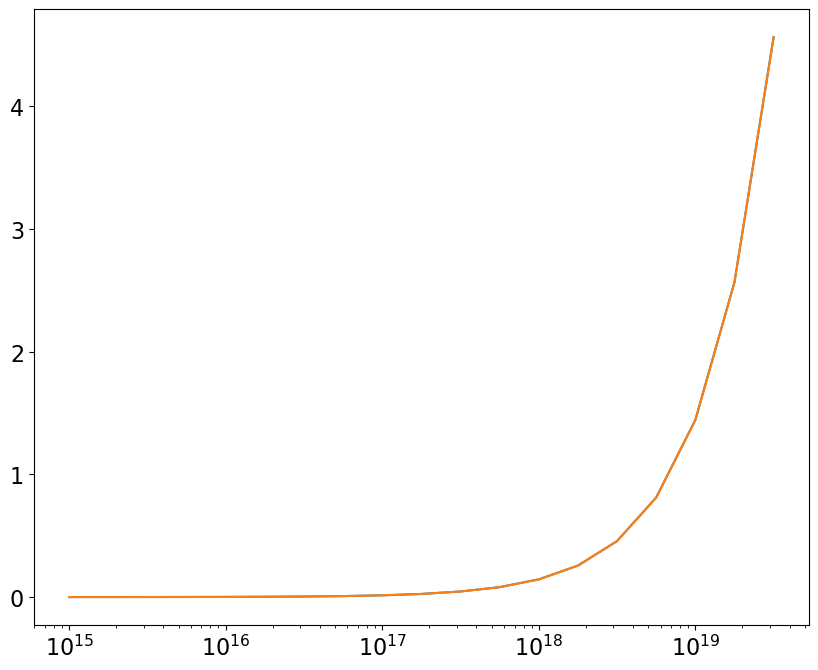

In [74]:
pl.semilogx(tb['column'][sel], a_color1)
pl.semilogx(tb['column'][sel], c1)

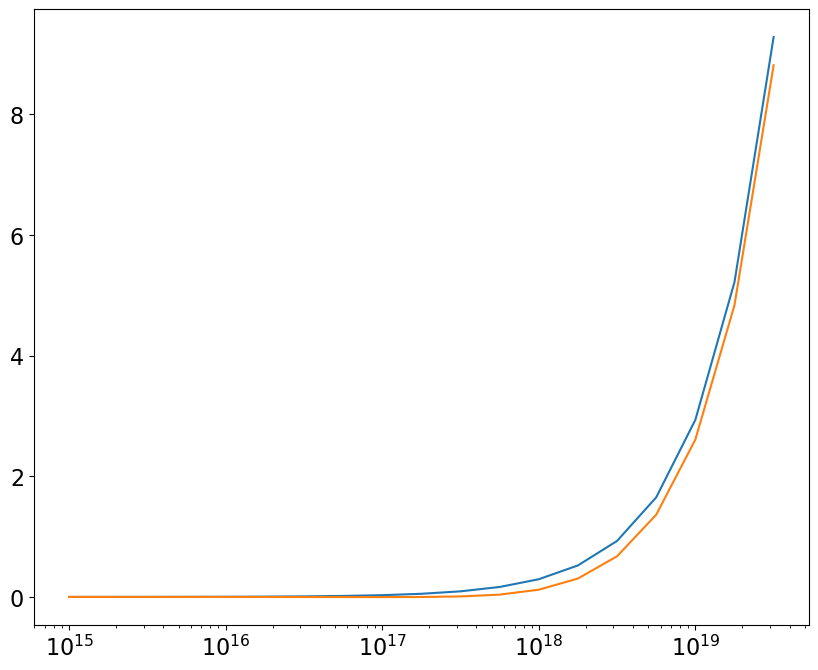

In [75]:
pl.semilogx(tb['column'][sel], a_color2)
pl.semilogx(tb['column'][sel], c2)

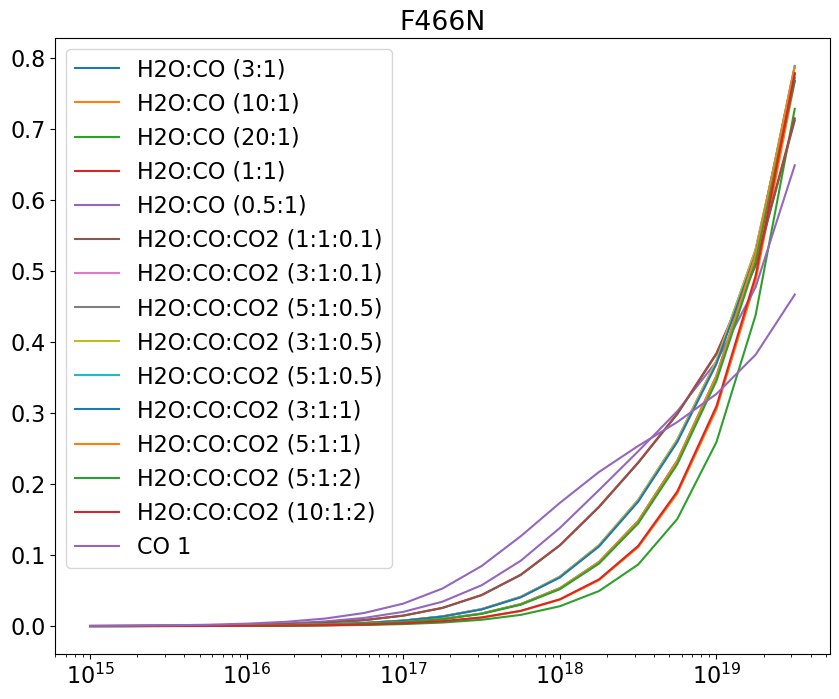

In [81]:
for molid in np.unique(dmag_mine['mol_id']):
    sel = dmag_mine.loc[molid]['column'] < 5e19
    comp = dmag_mine.loc[molid]['composition'][0]
    pl.semilogx(dmag_mine.loc[molid]['column'][sel], dmag_mine.loc[molid]['F466N'][sel], label=comp)
pl.title('F466N')
pl.legend(loc='best');

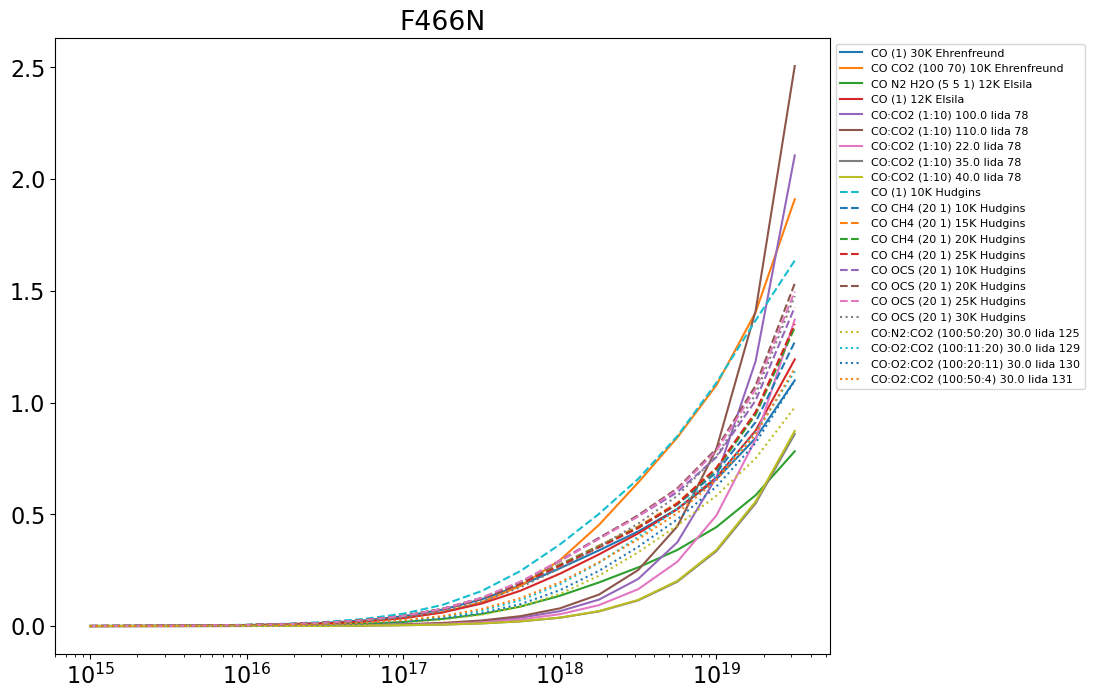

In [77]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F466N'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F466N");

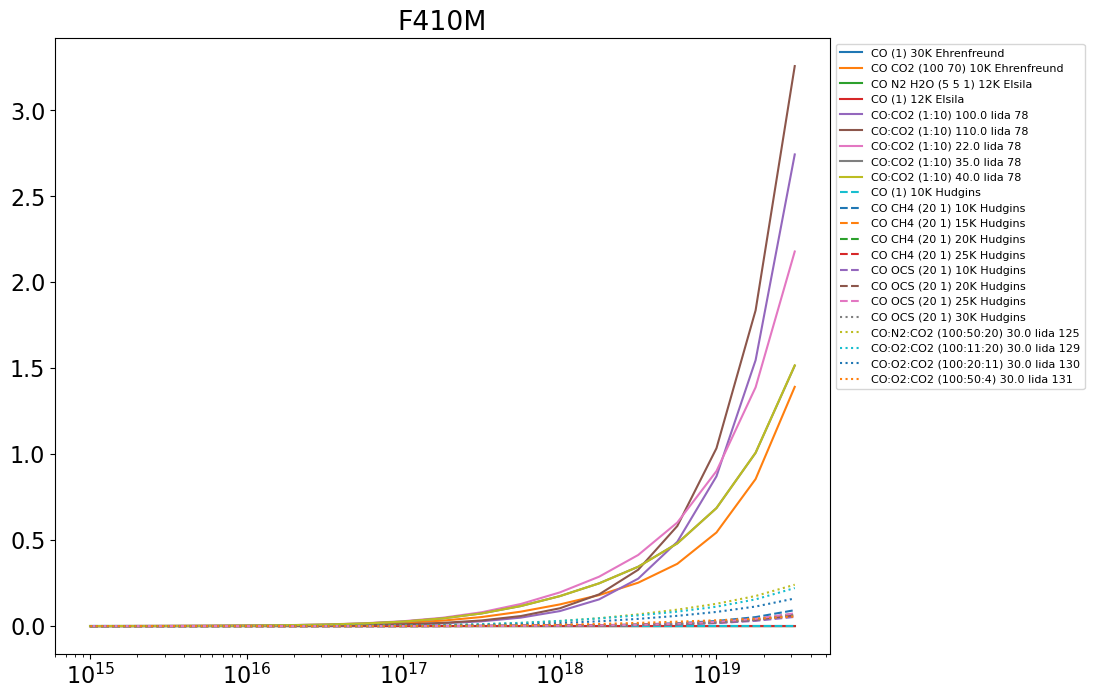

In [78]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F410M'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F410M");

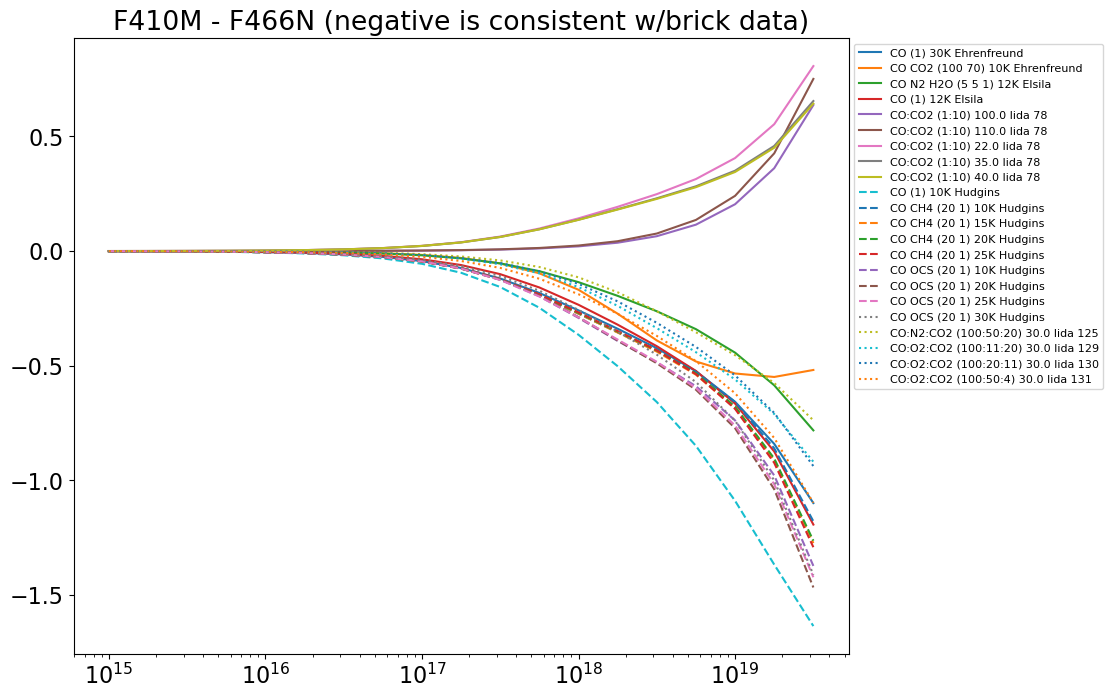

In [80]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        molwt = tb['molwt'][0]
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F410M'][sel] - tb['F466N'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F410M - F466N (negative is consistent w/brick data)");